#### Student Name: Kevin Cao
#### Student ID: A18315089


## Spectrograms, STFT and Griffin-Lim Phase Reconstruction

Instructions: 

This notebook is an interactive assignment; please read and follow the instructions in each cell.

Assignments are to be completed individually.

Cells that require your input (in the form of code or written response) will have 'Question #' above.

After completing the assignment, please submit this notebook.

# Seeing Sound Using Spectrograms

For this portion of the assignment, you will have the chance to see your own voice!
First, make two recordings of yourself:

In the first recording, you will say a vowel sound of your choice ("ah", "ee", "oo", etc.). Try to keep the sound short (no longer than you would make the vowel sound in a typical word ("car", "see", "good"). 

In the second recording, sing (or play on an instrument) any major scale, at a tempo of 60 bpm. (Don't worry, it doesn't need to be perfect- your best effort will be great!). 

Make sure both of your recordings are saved as mono WAV files. Audacity is a great tool to quickly convert audio file formats (and convert from stereo to mono). 

In [7]:
from music21 import midi as midi21
from music21 import stream
import copy
import music21
import soundfile as sf
from __future__ import  division
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
import scipy
from scipy import signal
import librosa
%matplotlib inline
import IPython.display as ipydisplay
from IPython.display import Audio, display

def setup_graph(title='', x_label='', y_label='', fig_size=None):
    fig = plt.figure()
    if fig_size != None:
        fig.set_size_inches(fig_size[0], fig_size[1])
    ax = fig.add_subplot(111)
    ax.set_title(title)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)

##### Question 1 [5 points]

In [8]:
### Modify the line below with your WAV file:
sample_rate, input_signal = wavfile.read("vowel.wav")
time_array = np.arange(0, len(input_signal)/sample_rate, 1/sample_rate)

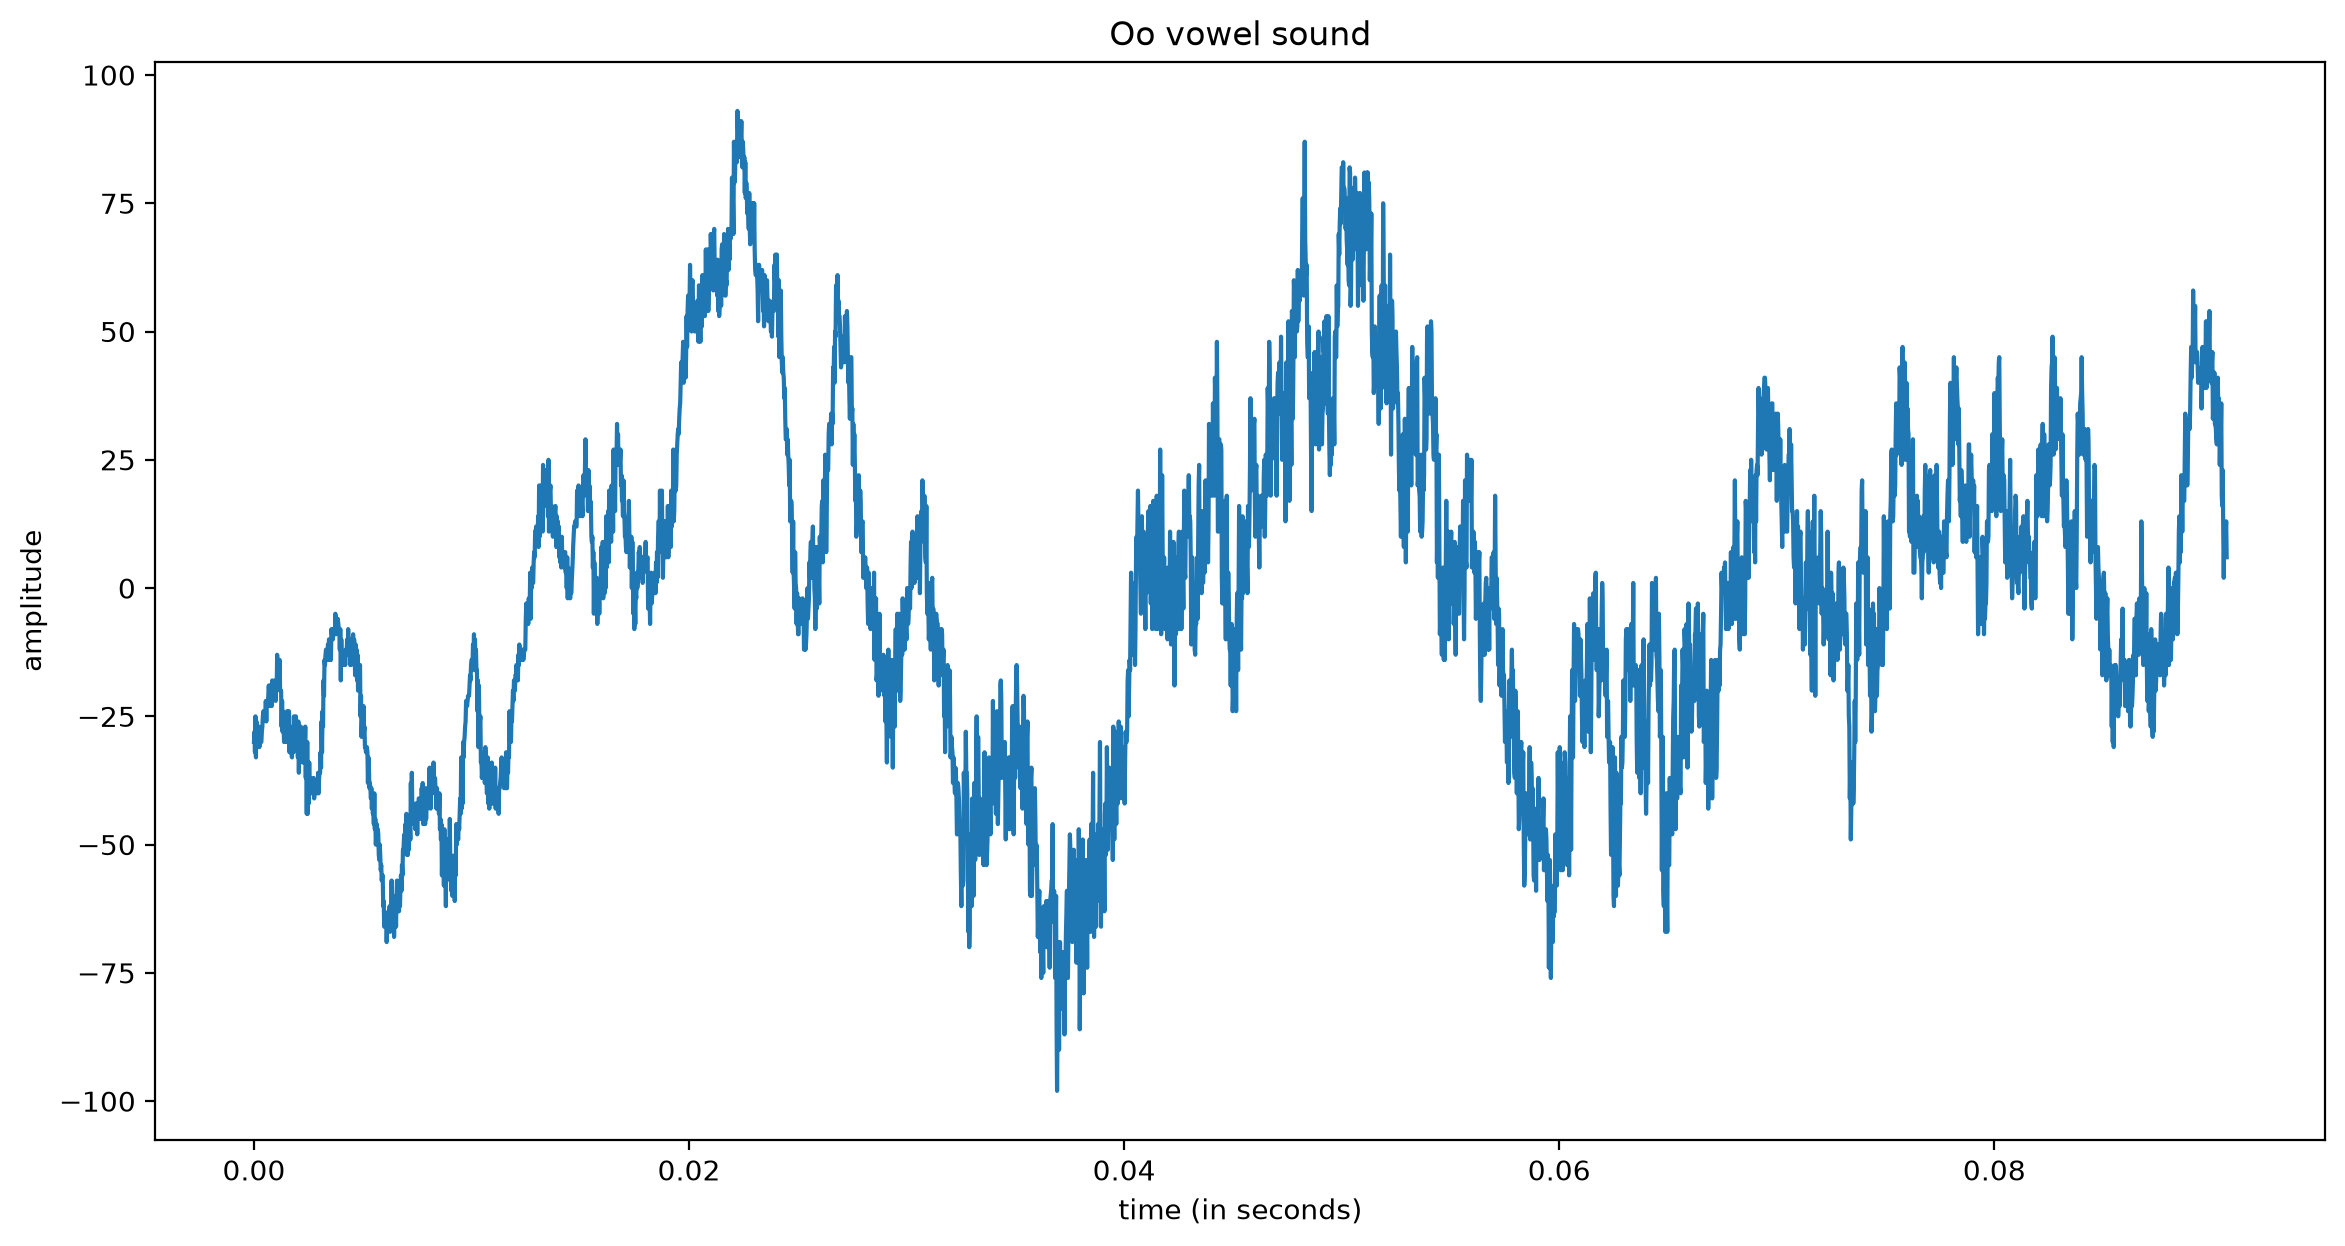

In [9]:
setup_graph(title='Oo vowel sound', x_label='time (in seconds)', y_label='amplitude', fig_size=(14,7))
_ = plt.plot(time_array[0:4000], input_signal[0:4000])

##### Question 2 [10 points]

The FFT of your input signal is complex valued (real and imaginary components). 
To visualize the output of the FFT of your input signal, we will calculate the magnitude of the FFT output.
In your code, you may want to make use of the .real and .imag members of the numpy complex128 class as you explore the fft_out datatype. 

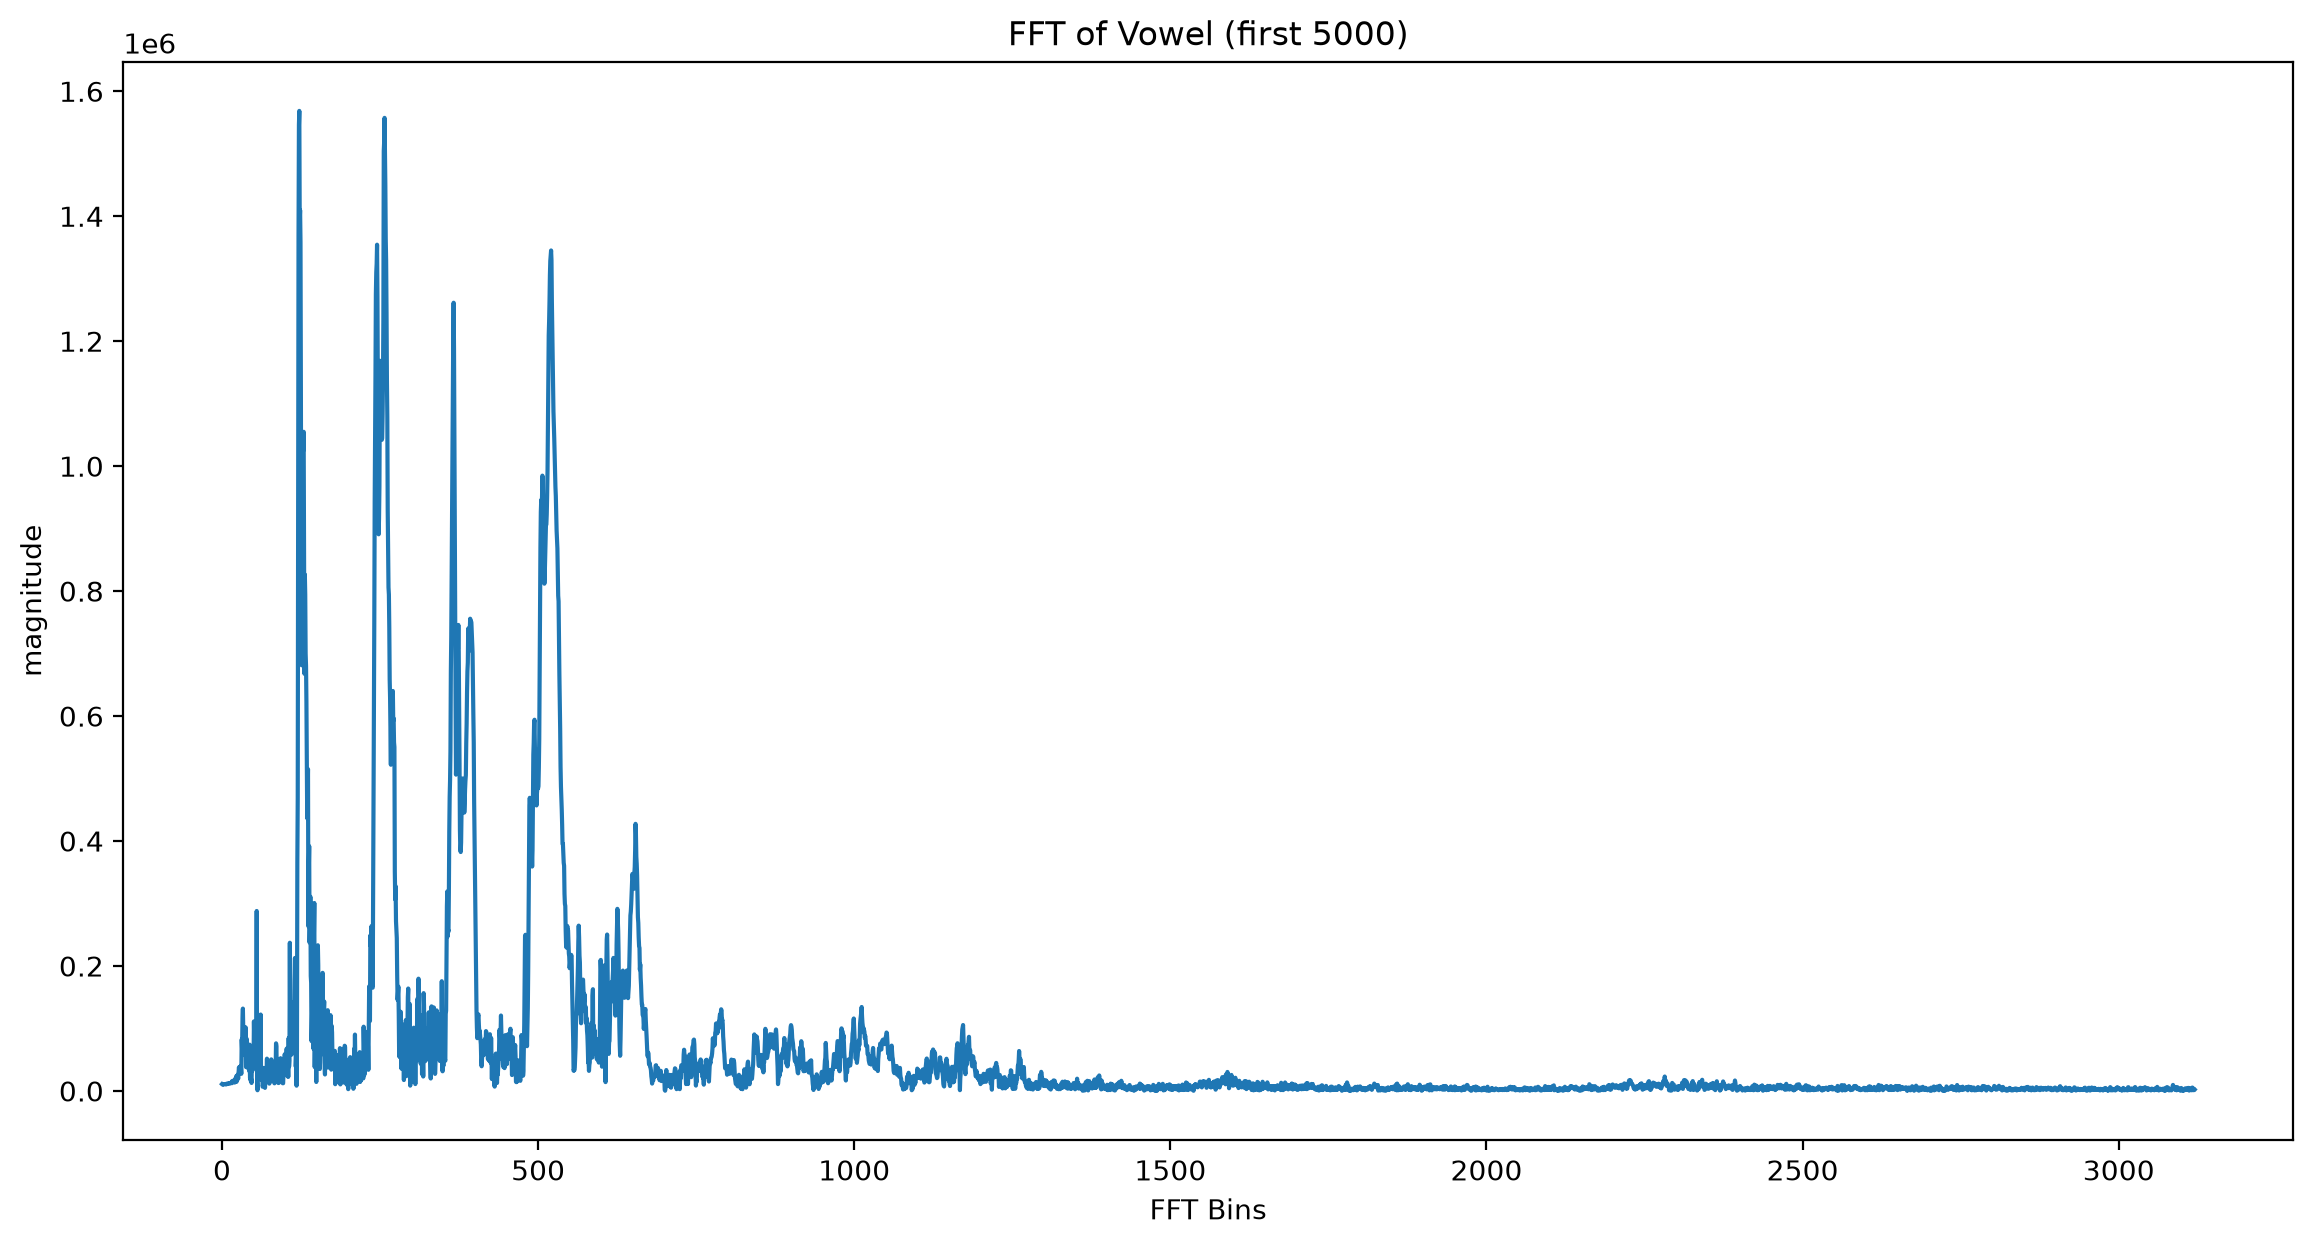

In [10]:
fft_out = np.fft.rfft(input_signal)

fft_mag = np.abs(fft_out)

num_samples = len(input_signal)
rfreqs = [(i*1.0/num_samples)*sample_rate for i in range(num_samples//2+1)]
setup_graph(title='FFT of Vowel (first 5000)', x_label='FFT Bins', y_label='magnitude', fig_size=(14,7))
_ = plt.plot(rfreqs[0:5000], fft_mag[0:5000])

##### Question 3 [10 points]

Would you expect another person's recording of the same vowel sound (on the same pitch and at the same volume) to have a similar FFT graph? What musical term is used to describe this quality? 

Yes, we would expect another person's recording of the same vowel, sung on the same pitch and at similar volume, to produce a broadly similar FFT graph. Both recordings should show energy concentrated at the same fundamental frequency (set by the pitch) with a similar harmonic series (integer multiples of the fundamental) above it, since the vowel sound is produced by periodic vocal-fold vibration filtered by a similarly shaped vocal tract resonance structure (formants). The musical/acoustic term for this shared harmonic-energy-distribution quality that lets us perceive it as the 'same' vowel/timbre is timbre (specifically, the vowel's relative formant structure). However, the two FFTs would not be identical, since each person's vocal tract has a different shape, which shifts the exact formant frequencies and produces individual voice-print differences.

# Spectrogram (FFT over time)

### Axes

* x-axis: time
* y-axis: frequency
* z-axis (color): strength of each frequency

### See the Harmonics!

##### Question 4 [5 points]

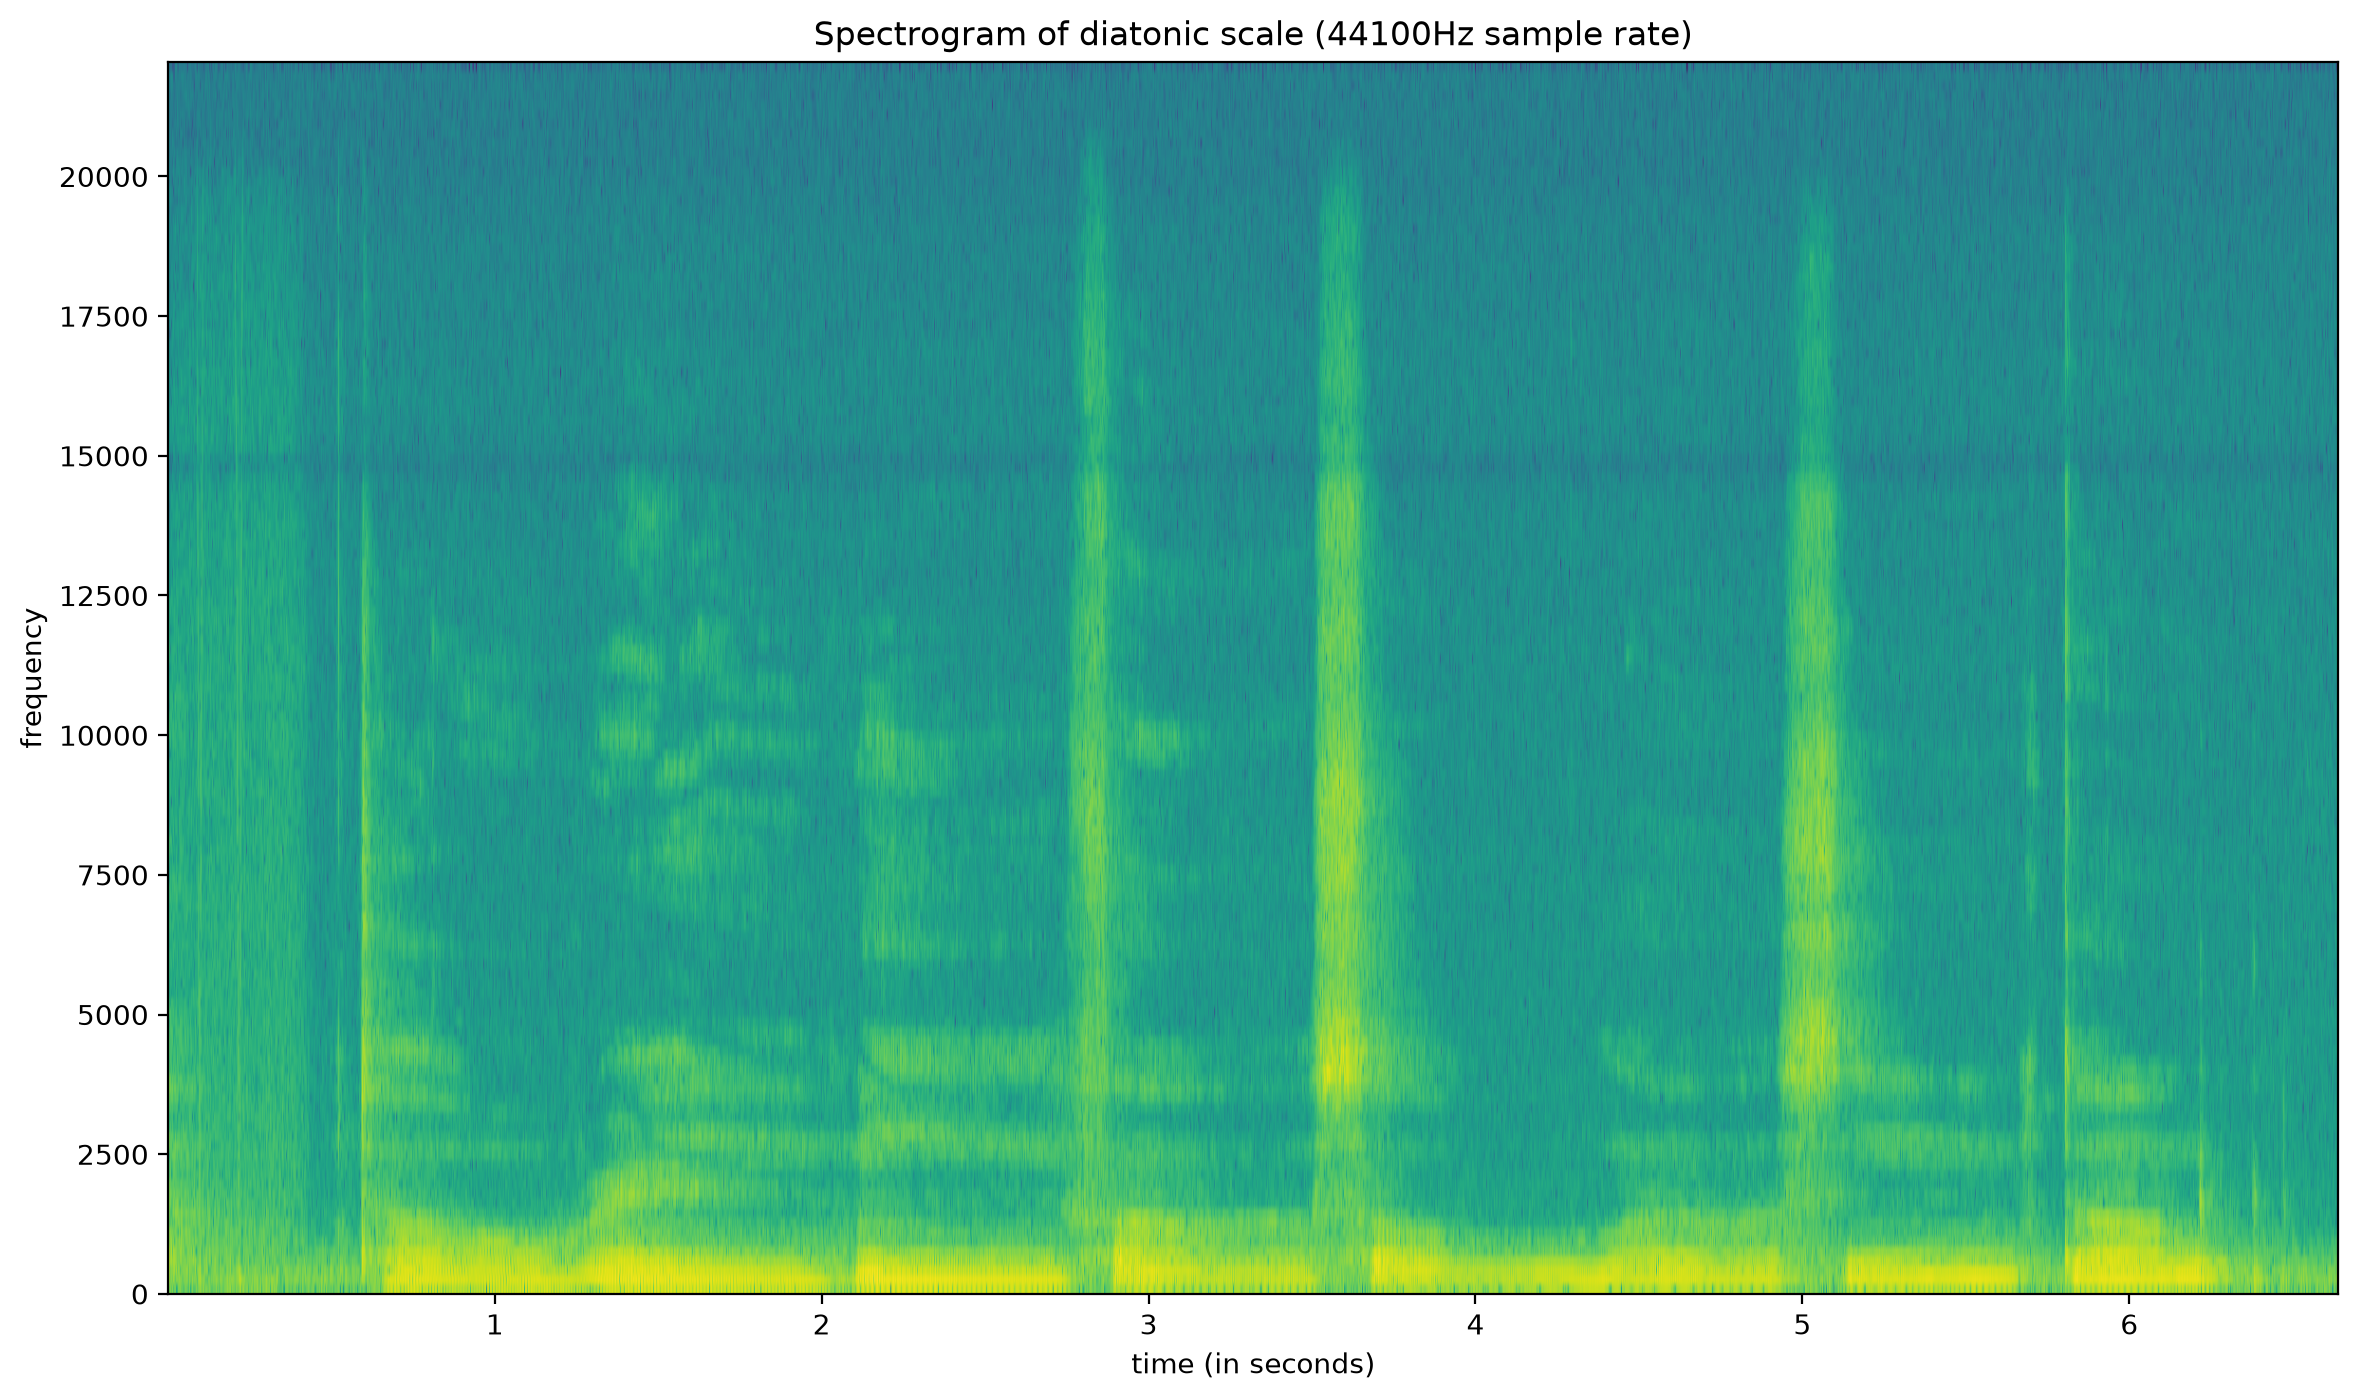

In [11]:
### Modify the line below:
sample_rate, sample = wavfile.read("singing.wav")

setup_graph(title='Spectrogram of diatonic scale (%dHz sample rate)' % sample_rate, x_label='time (in seconds)', y_label='frequency', fig_size=(14,8))
_ = plt.specgram(sample, Fs=sample_rate)

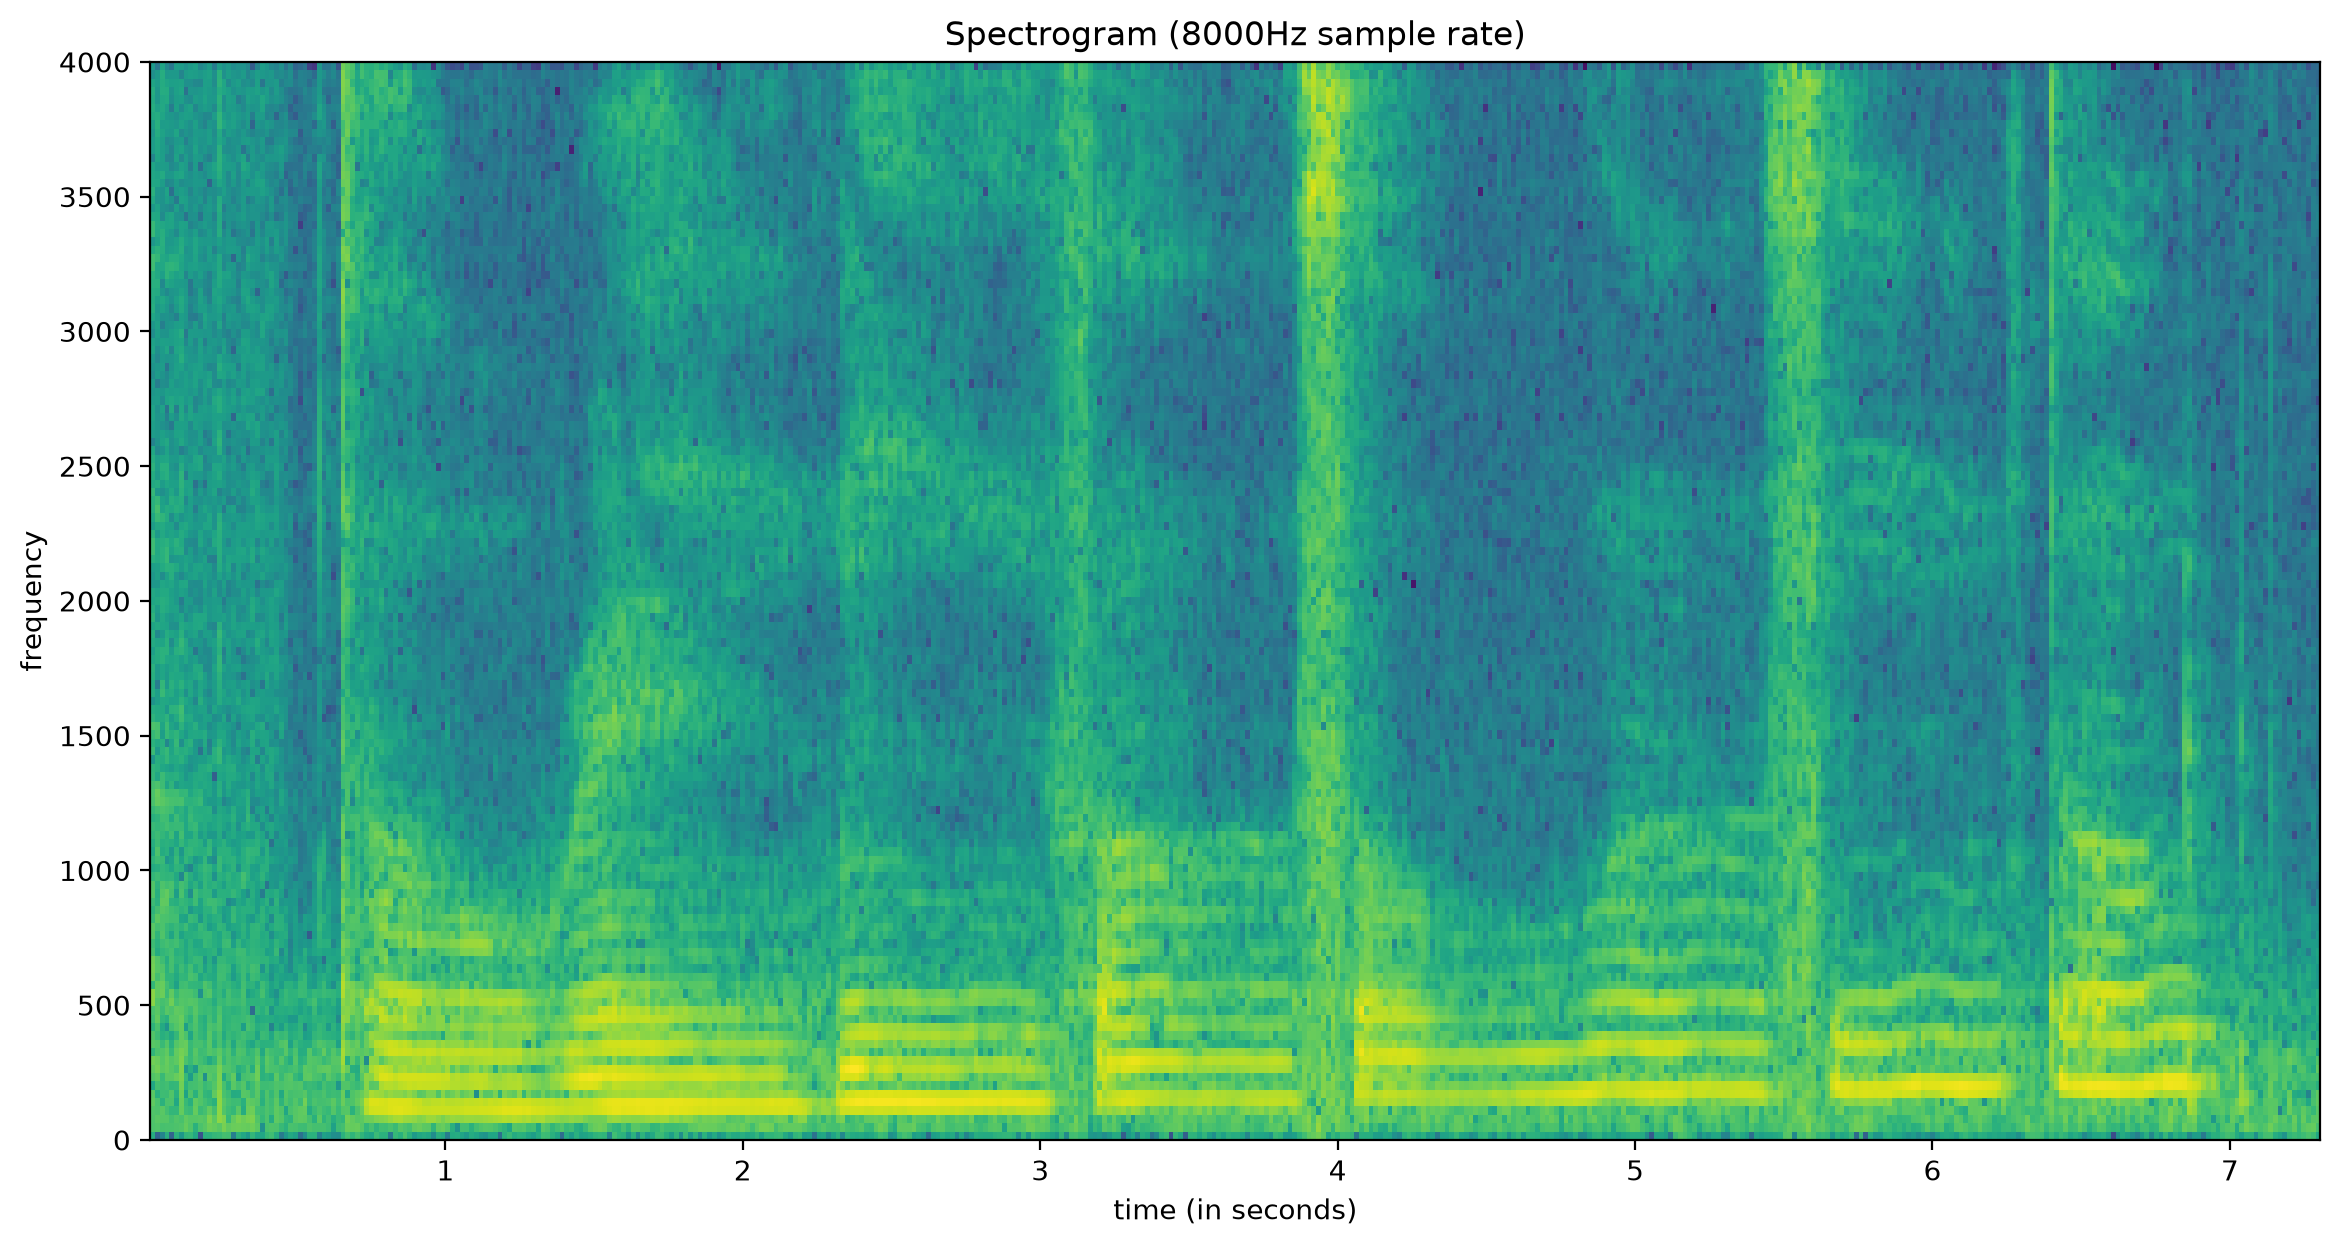

In [12]:
sample_8000hz = [sample[i] for i in range(0, len(sample), sample_rate//8000)]
setup_graph(title='Spectrogram (8000Hz sample rate)', x_label='time (in seconds)', y_label='frequency', fig_size=(14,7))
_ = plt.specgram(sample_8000hz, Fs=8000)

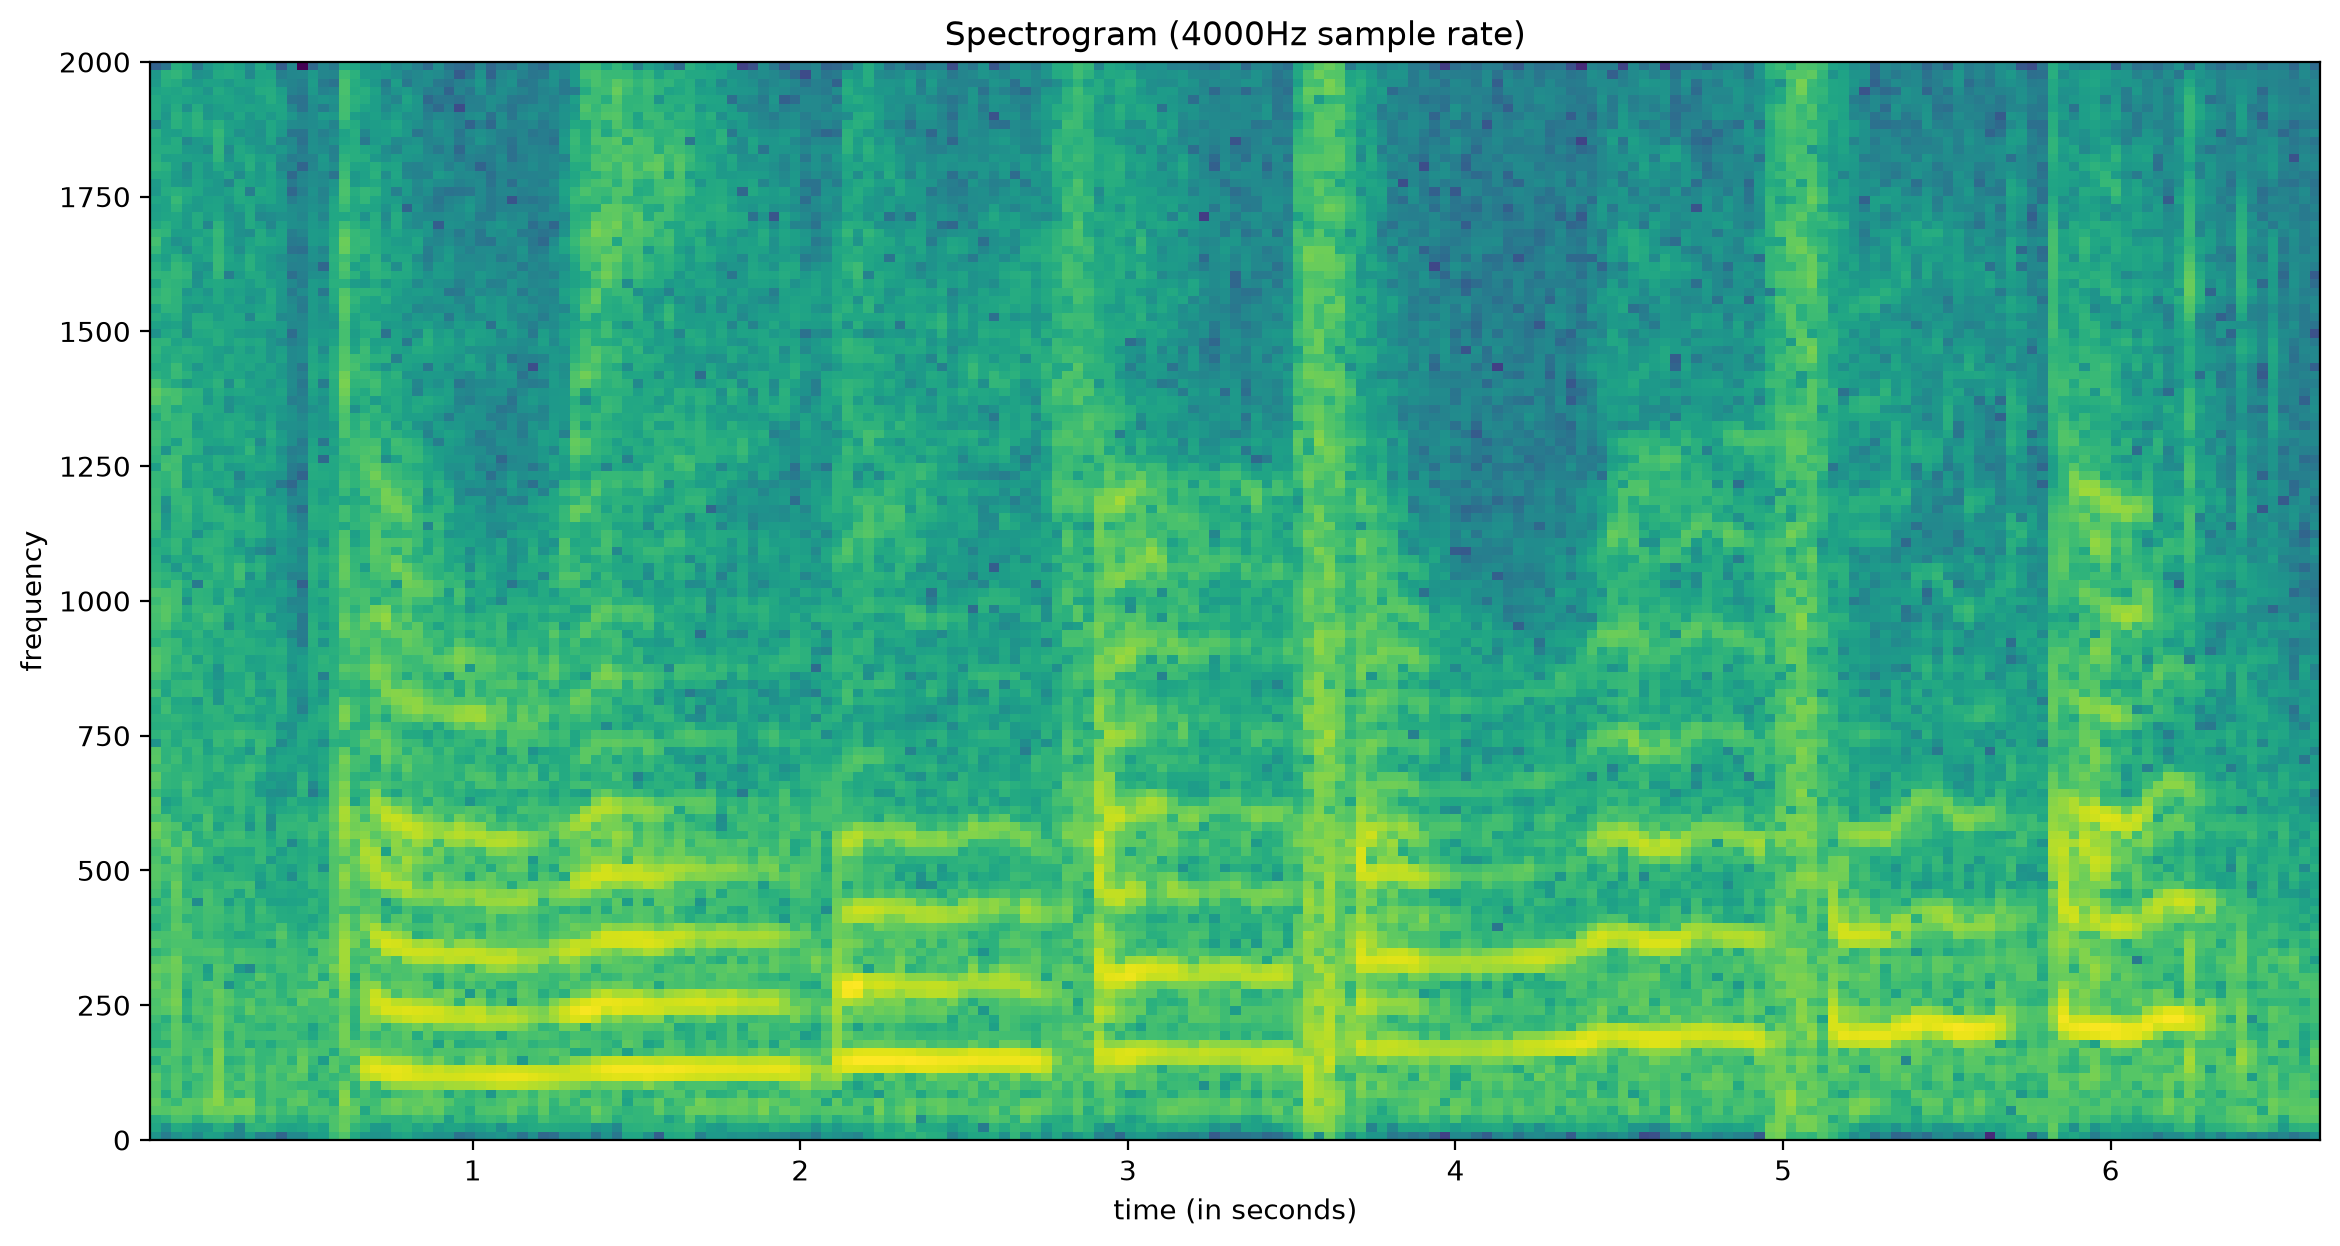

In [13]:
sample_4000hz = [sample[i] for i in range(0, len(sample), sample_rate//4000)]
setup_graph(title='Spectrogram (4000Hz sample rate)', x_label='time (in seconds)', y_label='frequency', fig_size=(14,7))
_ = plt.specgram(sample_4000hz, Fs=4000)

In your recording, you were singing (or playing) a single note at a time. Does this still appear to be the case when looking at the spectrogram of your recording? What are you observing? 

What would you expect the relationship between the first and last note on your spectrogram to be? Is this the case?  

In the spectrogram, even though only a single note is being played/sung at any given moment, we can still see multiple horizontal bands stacked on top of each other at each time step. This is because a sung or played note is not a pure sine wave — it is a periodic waveform made up of a fundamental frequency plus a series of harmonics (integer multiples of the fundamental) that are naturally present due to the physics of vocal cords/instrument resonance. So although the ear perceives 'one note,' the spectrogram shows the fundamental as the lowest, brightest band, with fainter harmonic bands rising above it in parallel, all moving together in time as the pitch changes.

For a diatonic major scale, we would expect the last note (the octave) to be exactly twice the frequency of the first note (the tonic), since an octave corresponds to a 2:1 frequency ratio. Looking at the spectrogram, this relationship generally holds: the fundamental frequency band of the last note appears at roughly double the frequency (twice as high vertically) as the fundamental of the first note, and its harmonic bands align closely with alternating harmonics of the first note (since the octave's harmonic series is a subset of the tonic's harmonic series).

##### Question 5 [10 points]

Note that the way naive resampling method is done above is theoretically incorrect. Can you explain why? Read about the resampling method in other signal processing libraries such as librosa. 

The naive resampling method used above simply picks every Nth sample from the original signal (i.e., decimation without filtering). This is theoretically incorrect because it violates the Nyquist–Shannon sampling theorem: before downsampling, the signal must first be low-pass filtered to remove any frequency content above the new Nyquist frequency (half of the new, lower sample rate). Skipping this anti-aliasing filter causes high-frequency content in the original signal to fold back (alias) into the lower frequency range of the downsampled signal, corrupting the result with spurious frequency components that were not present in the original sound. Proper resampling libraries such as librosa.resample() (which uses band-limited sinc interpolation / polyphase filtering under the hood, e.g., via resampy or soxr) apply this anti-aliasing low-pass filter automatically before or during the rate conversion, avoiding this aliasing artifact.

##### Question 6 [20 points]

Do another 1000 Hz resampling twice: once using the naive method above and second time using a proper downsampling. Plot both spectrograms. Can you detect a difference? 


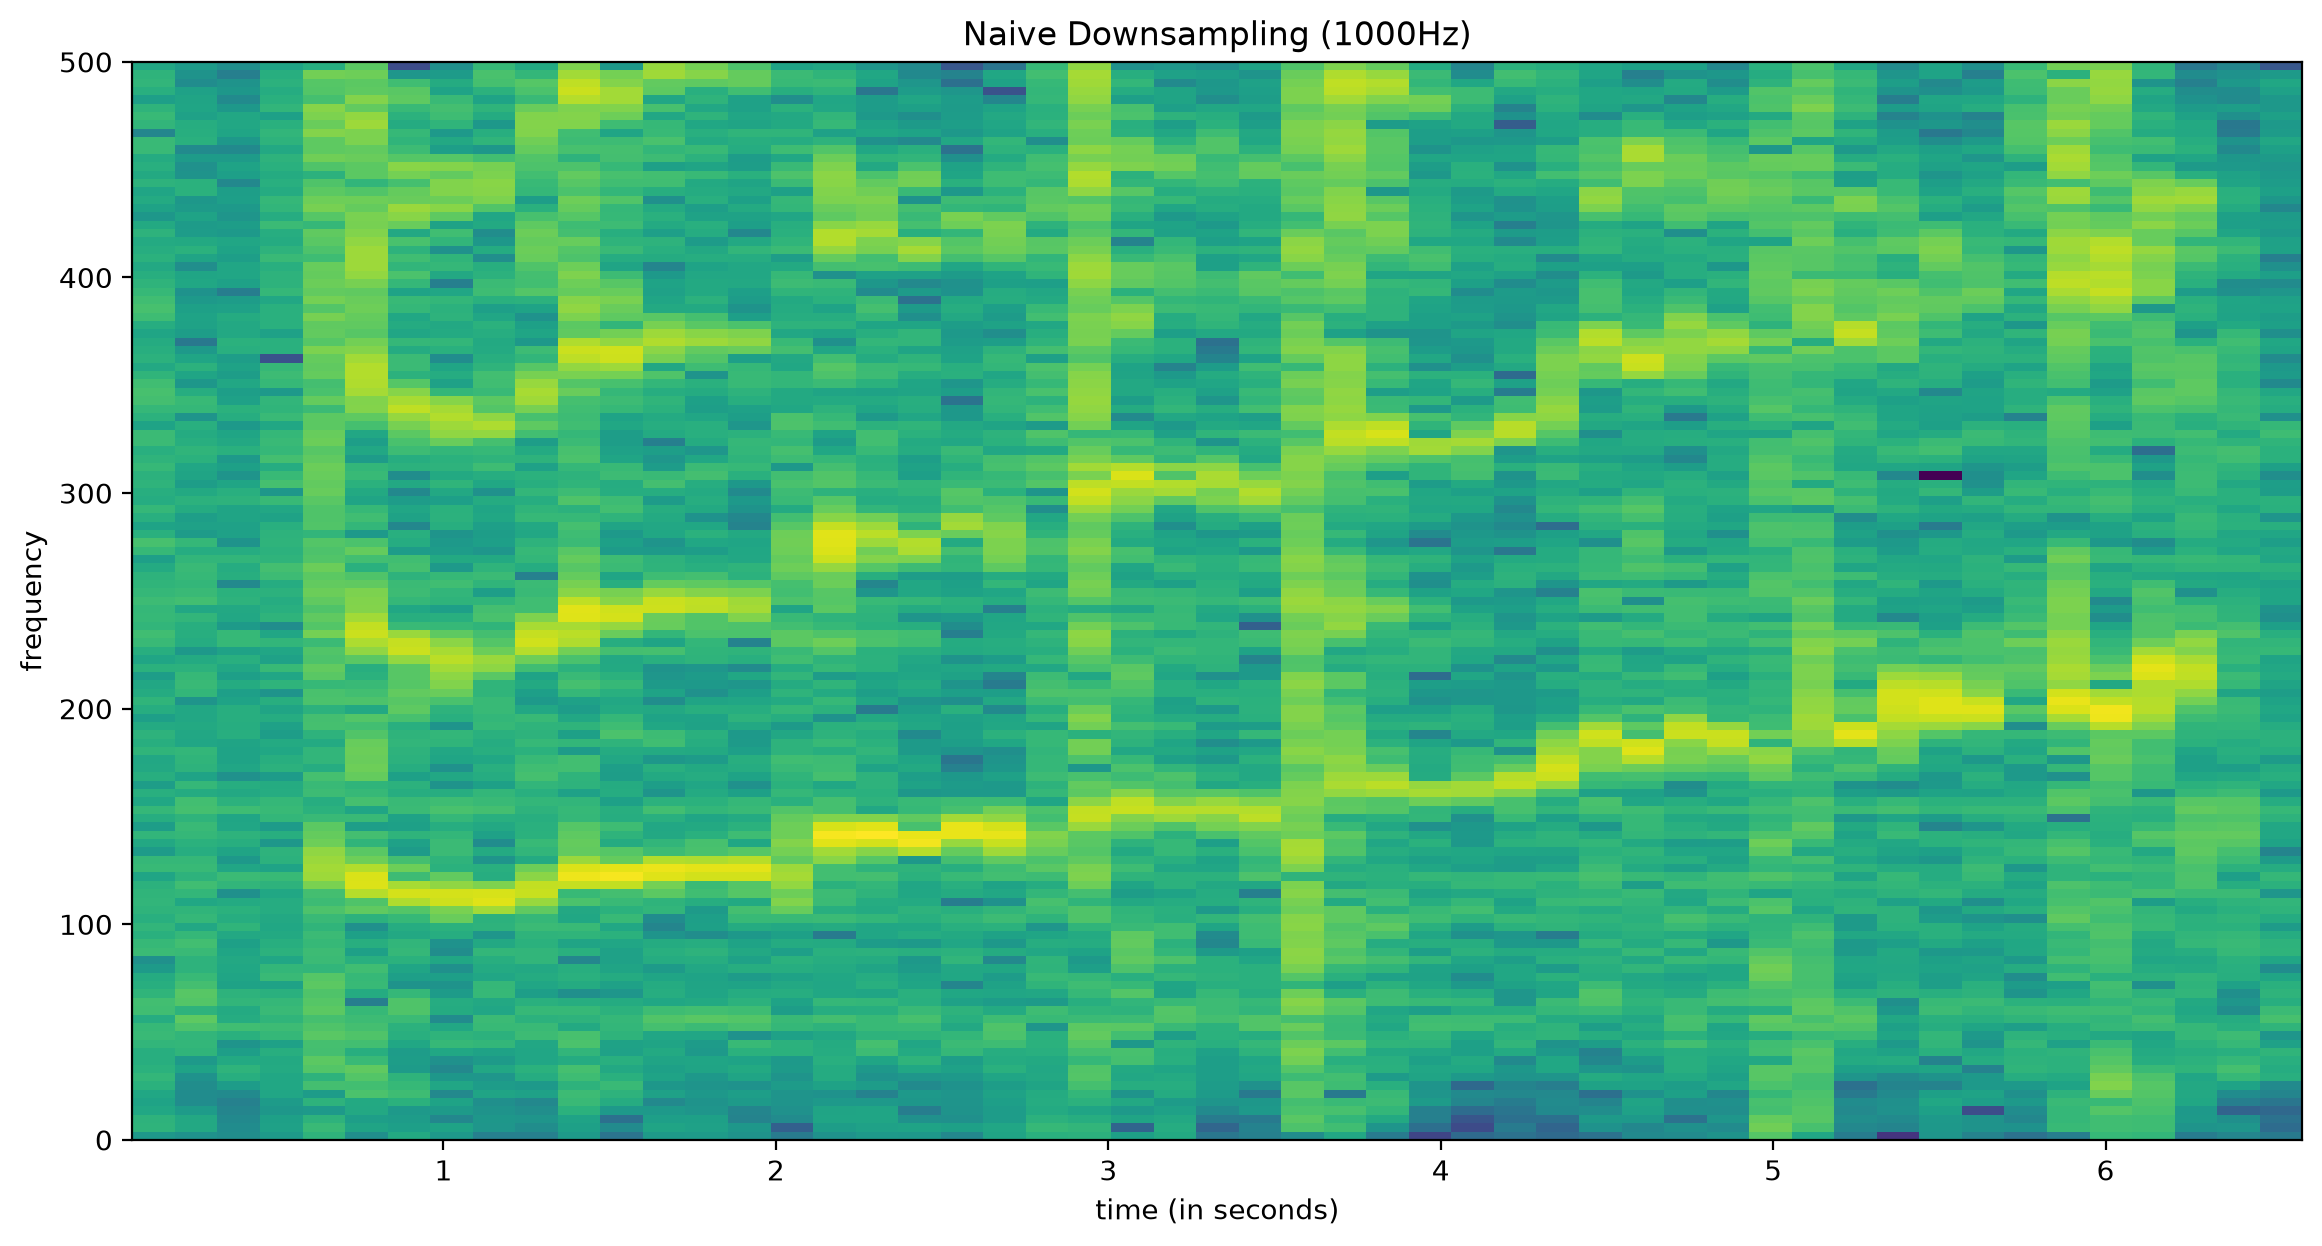

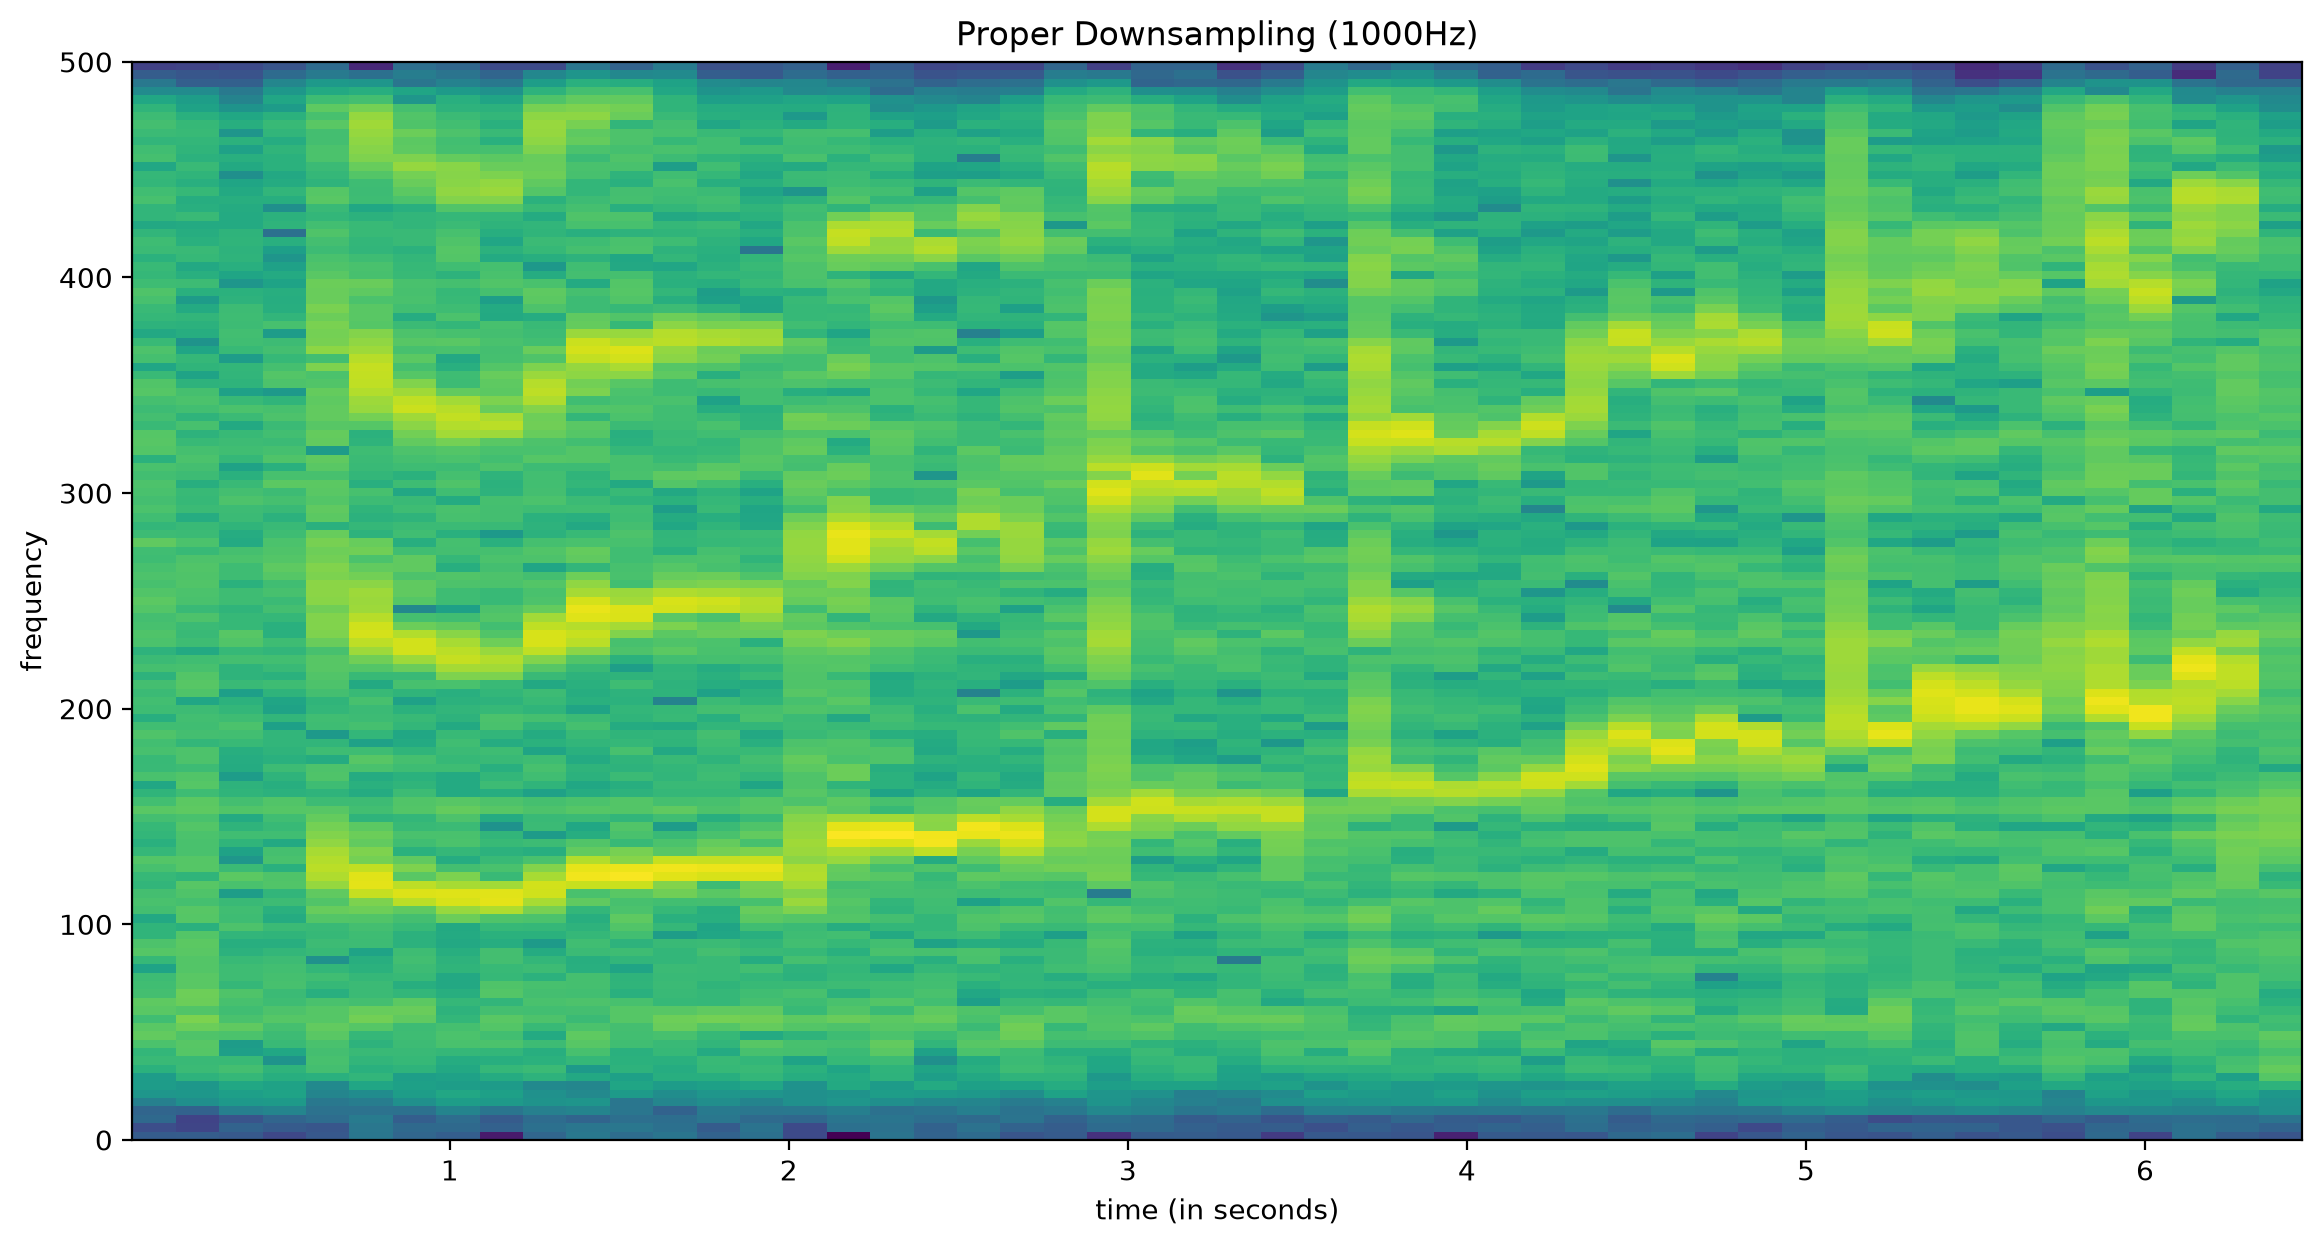

In [14]:
### Your code here

import librosa as lb

# Naive downsampling (simple decimation, no anti-aliasing filter)
sample_naive_1000hz = [sample[i] for i in range(0, len(sample), sample_rate//1000)]

# Proper downsampling (using librosa's resample, which applies anti-aliasing filtering)
sample_float = sample.astype(np.float32)
sample_proper_1000hz = lb.resample(sample_float, orig_sr=sample_rate, target_sr=1000)

setup_graph(title='Naive Downsampling (1000Hz)', x_label='time (in seconds)', y_label='frequency', fig_size=(14,7))
_ = plt.specgram(sample_naive_1000hz, Fs=1000)

setup_graph(title='Proper Downsampling (1000Hz)', x_label='time (in seconds)', y_label='frequency', fig_size=(14,7))
_ = plt.specgram(sample_proper_1000hz, Fs=1000) 

Yes, a difference is clearly visible between the two spectrograms. The naively downsampled version shows extra, spurious low-frequency energy and noisy/blurred bands that were not present in the original recording — this is aliasing, caused by high-frequency content (near and above the new Nyquist frequency of 500 Hz) folding back into the lower frequency range because no anti-aliasing filter was applied before decimation. The properly downsampled version, which uses band-limited resampling with a built-in low-pass anti-aliasing filter, shows a cleaner spectrogram where the harmonic bands are more clearly separated and free of the extraneous artifacts, more faithfully preserving only the frequency content that is actually representable at 1000 Hz.

# Spectrogram inversion from spectral amplitude

Short-time Fourier Transform (STFT) analysis takes short snapshots of sound and represents them as a matrix of fft vectors.
As we saw above, the fft is a complex transform that contain information about amplitude and phase of each frequency component. In many applications we choose to discard the phases and use the amplitudes only. 

One challenge is to reconstruct the original waveform from amplitude information only.

For these questions, we will explore an iterative method by Griffin and Lim.

Let's start with creating spectral amplitudes of your earlier vowel WAV file:

##### Question 7 [5 points]

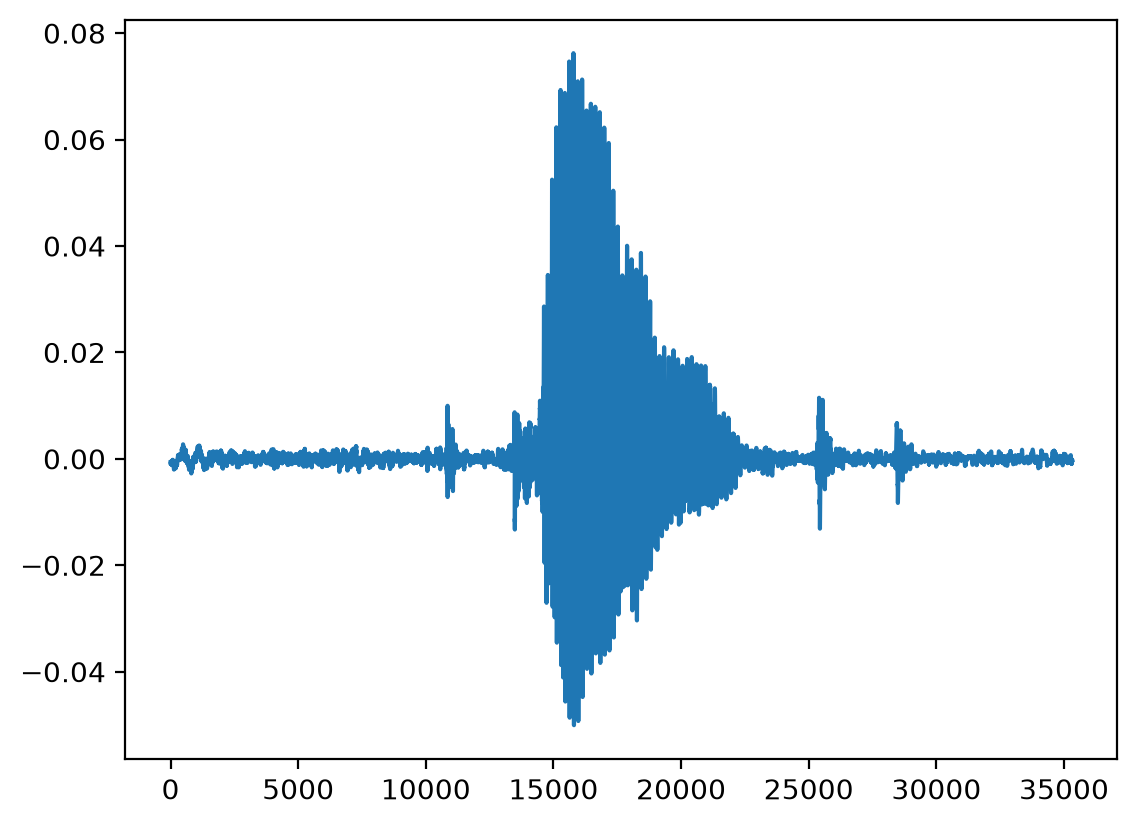

In [15]:
# Reads wav file and produces spectrum
# Fourier phases are ignored

def wave_to_spectum(x, n_fft):
    S = librosa.stft(x, n_fft = n_fft)
    p = np.angle(S)   
    A = np.log1p(np.abs(S))  
    return A

### Replace the string below with your file:
filename = 'vowel.wav'
x, fs = librosa.load(filename)
n_fft = 2048
plt.plot(x)
SA = wave_to_spectum(x, n_fft)

In [16]:
ipydisplay.Audio(data=x, rate=fs)

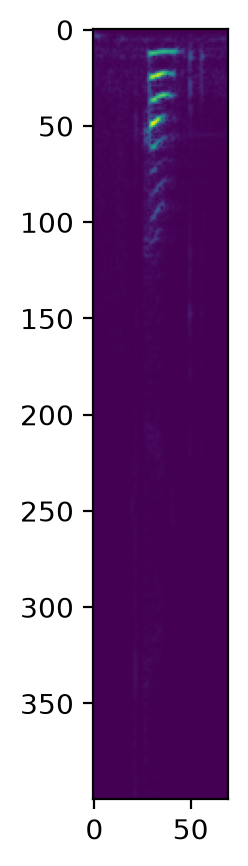

In [17]:
plt.figure(figsize=(15,5))
plt.imshow(SA[:400,:])
plt.show()

## Griffin and Lim method

In the next code block, you will implement the Griffin and Lim iterative method for phase reconstruction.
Please look over the pseudocode available on pg. 1865 of Wakabayashi & Ono's 2019 paper, available at http://www.apsipa.org/proceedings/2019/pdfs/290.pdf

The random phase initialization is provided as p. Please use 1000 iterations for your reconstruction. 

You may find the librosa functions istft and stft helpful in your implementation. 

##### Question 8 [30 points]

In [ ]:
def writespectrumwav(a, NFFT):
    """
    Given input amplitude a, return reconstructed signal x
    using the Griffin-Lim iterative method.
    """
    a = np.exp(a) - 1
    p = 2 * np.pi * np.random.random_sample(a.shape) - np.pi

    for i in range(1000):
        S = a * np.exp(1j * p)
        x = librosa.istft(S, win_length=NFFT)
        p = np.angle(librosa.stft(x, n_fft=NFFT))

        if i % 100 == 0:
            print(i * 100 / 1000, 'percent completed')

    return x

xout = writespectrumwav(SA, nfft)

Now we can compare your reconstruction to the original signal, both auditorily and visually: 

In [19]:
OUTPUT_FILENAME = 'out.wav'
sf.write(OUTPUT_FILENAME, x_out, fs)
display(Audio(OUTPUT_FILENAME))

In [20]:
display(Audio(filename))

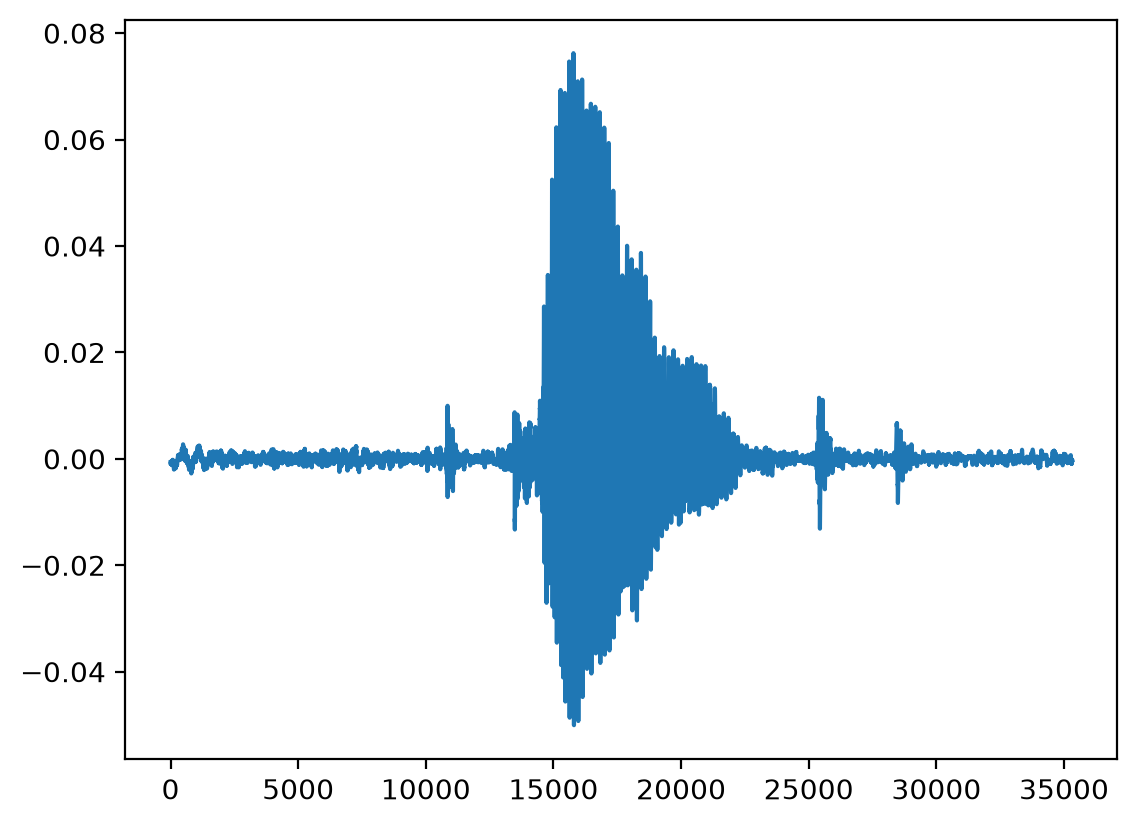

In [21]:
plt.plot(x)

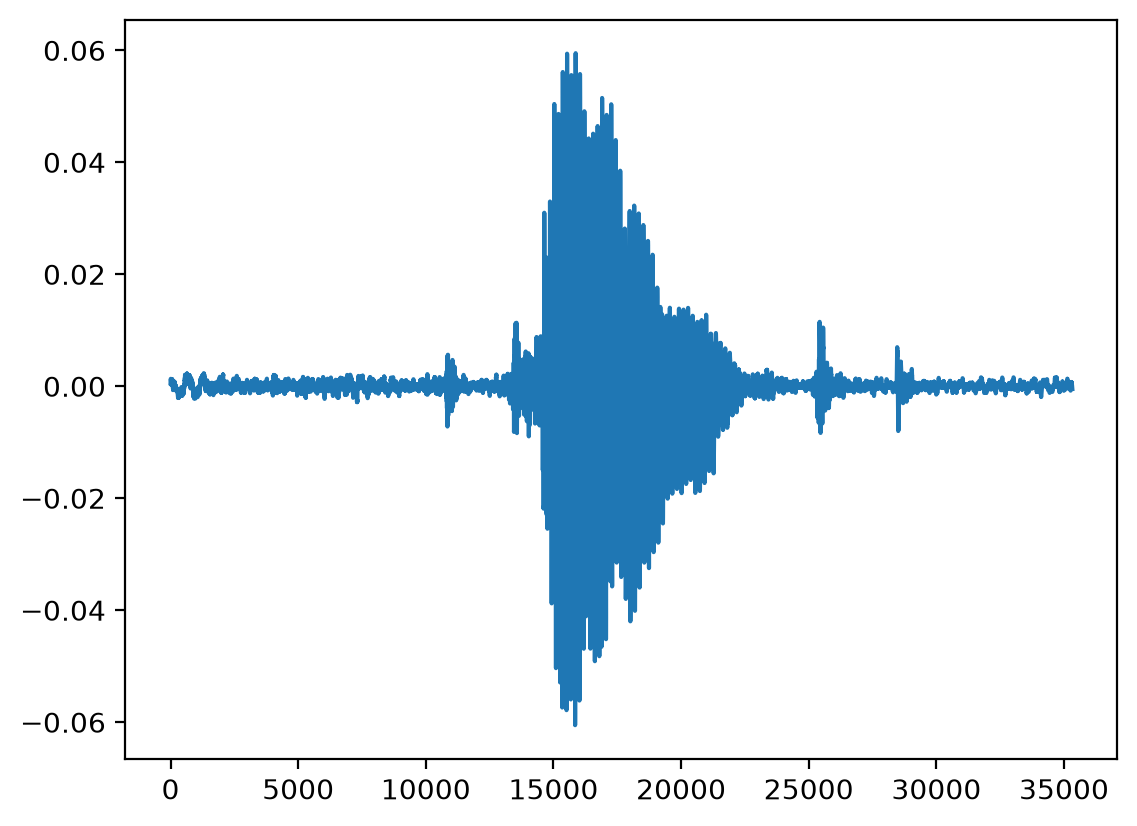

In [22]:
plt.plot(x_out)

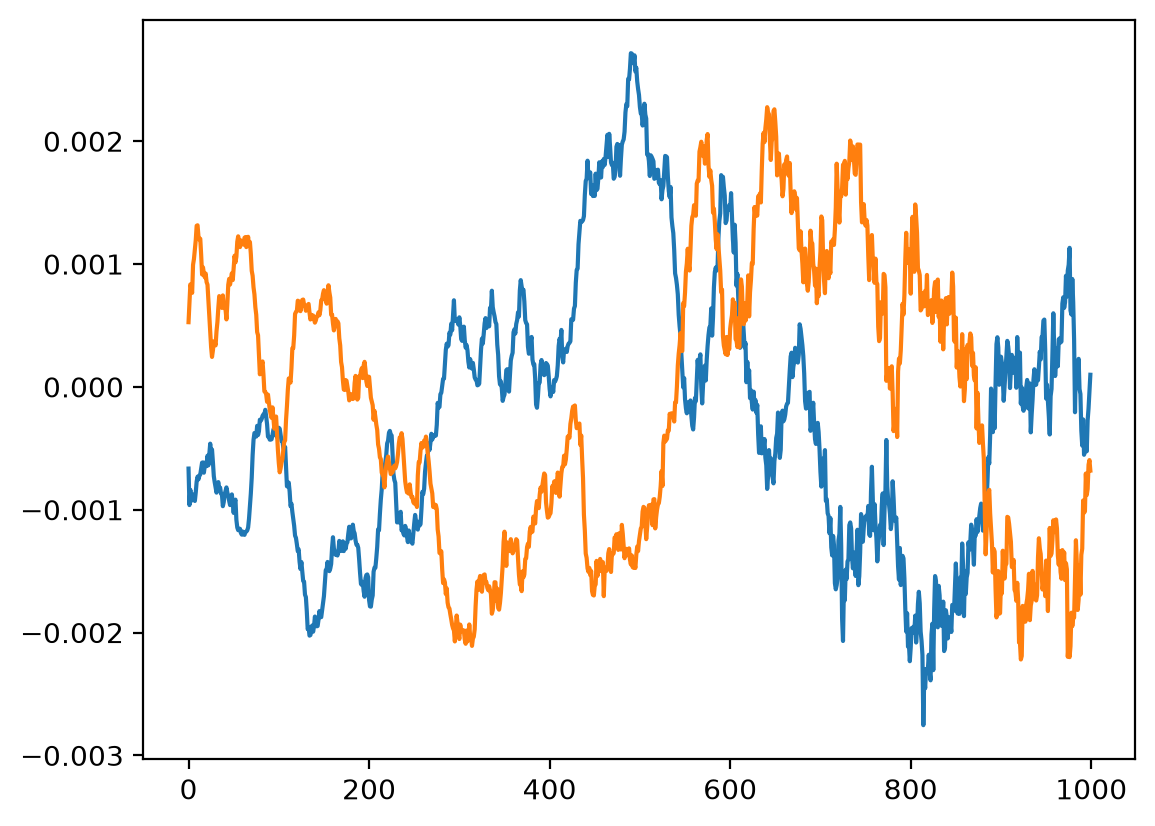

In [23]:
plt.plot(x[:1000])
plt.plot(x_out[:1000])

The Griffin and Lim method is not a perfect reconstruction.
Let's compare this to directly inverting the complex specta from STFT:

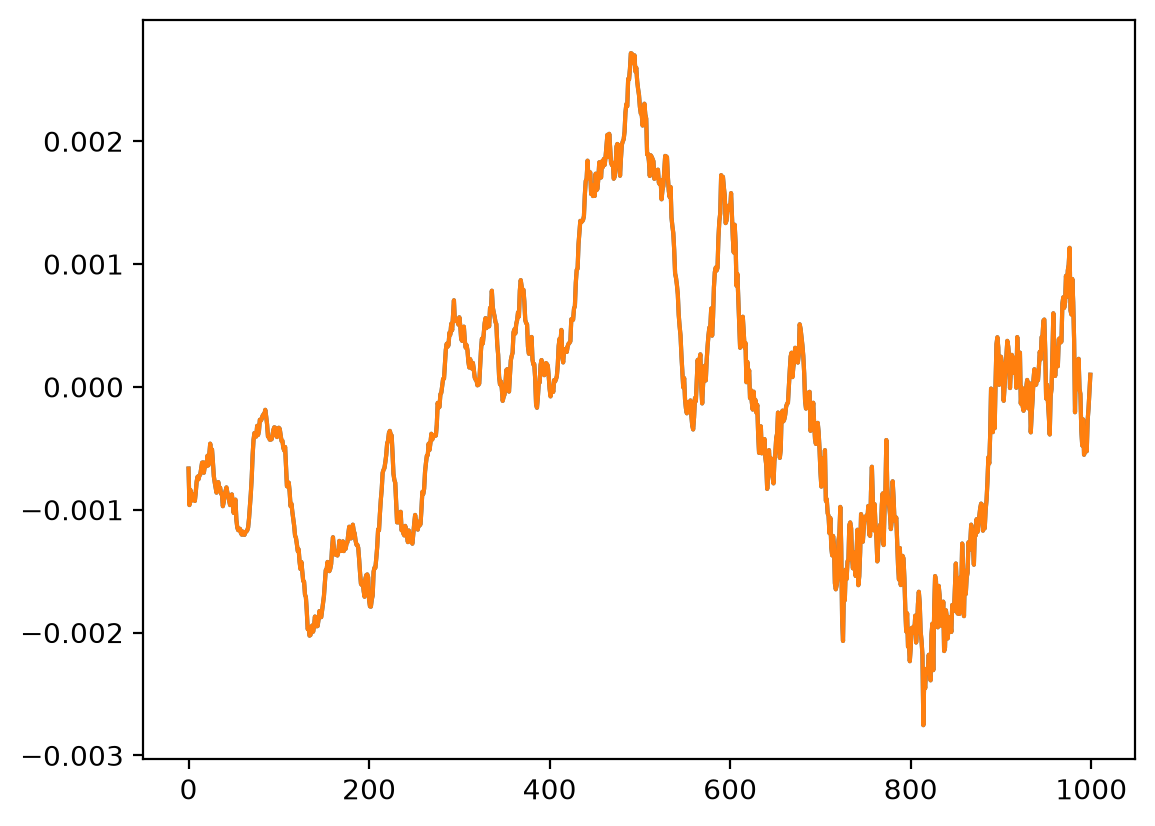

In [24]:
S = librosa.stft(x, n_fft = n_fft)
x_inv = librosa.istft(S, win_length=n_fft)
plt.plot(x[:1000])
plt.plot(x_inv[:1000])

##### Question 9 [5 points]

Describe the difference between the Griffith & Lim and the perfect reconstruction. Does it sound similar? Can you see the difference in the waveform?

The Griffin & Lim reconstruction and the perfect (direct complex ISTFT) reconstruction sound very similar overall — the pitch, rhythm, and overall vowel timbre are recognizable in both but the Griffin & Lim version has a noticeably more 'watery,' slightly metallic or phasey quality, since it only estimates the phase iteratively rather than using the true original phase information. Looking at the waveform plots, the perfect reconstruction (x_inv) lines up almost exactly with the original signal x sample-for-sample, while the Griffin & Lim output (x_out) follows the same general envelope and periodicity but has visible small-scale differences in the exact sample values, reflecting the fact that its recovered phase is only an approximation of the true phase, not an exact match.